# Hello, We're in Random Forest Classifier🎯🥹
If you're reading this, it's a notebook file of my *skripsi* (bachelor's thesis) on **Cybersecurity**. I applied machine learning classifications using sklearn on **my campus network flow** (not packets). Hope you get any knowledge through my experiments and exploration on machine learning practically, please, have fun! 🤘🏻

Ask me questions on social media:  
Linked-in: https://www.linkedin.com/in/rayyan-eka-putra/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Datasets Exploration 📃

### 1. Cleaning

Importing

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/Skripsi/Preprocessing/notebooks_skripsi/TEKNIK2024_Datasets.csv", low_memory=False)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Making sure there are no 'Unmarked' features imported
df = df.loc[:, 'time_spent':]
df.head(10)

,time_spent,uid,originh,originp,responh,responp,protocol,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,bwd_last_window_size,Target,Activity
0,1.702370e+09,C0y5LWOhg3eHFPRG4,61.155.106.101,39154,192.168.1.2,22,tcp,0.000000,0,1,0,0,0.000000,0.000000,0.000000,0.000000,0,0,0,32,32,32,1,0,0,0,0,1,0,0,0,0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0,510,0,510,Malicious,Bruteforce SSH
1,1.702370e+09,CplqcW2DwYpyMnxyLj,61.155.106.101,39154,10.163.10.244,22,tcp,0.000000,0,1,0,0,0.000000,0.000000,0.000000,0.000000,0,0,0,32,32,32,1,0,0,0,0,1,0,0,0,0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0,510,0,510,Malicious,Bruteforce SSH
2,1.702370e+09,CNYARk3Mh1o0SbTsZ,71.56.93.87,39994,192.168.1.2,23,tcp,0.000537,1,1,0,0,1862.479574,1862.479574,3724.959147,1.000000,24,24,24,20,20,20,0,1,1,0,0,1,0,0,0,0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,536.918640,5.369186e+02,5.369186e+02,536.918640,0.000000,0.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,5.369186e+02,5.369186e+02,5.369186e+02,5.369186e+02,0.0,0.0,0.0,0.0,0.0,0.0,53090,0,53090,0,Malicious,Bruteforce Telnet
3,1.702370e+09,Cy34X12WkAg4frsIqg,71.56.93.87,39994,10.163.10.244,23,tcp,0.000566,1,1,0,0,1766.766639,1766.766639,3533.533277,1.000000,24,24,24,20,20,20,0,1,1,0,0,1,0,0,0,0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,566.005707,5.660057e+02,5.660057e+02,566.005707,0.000000,0.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,5.660057e+02,5.660057e+02,5.660057e+02,5.660057e+02,0.0,0.0,0.0,0.0,0.0,0.0,53090,0,53090,0,Malicious,Bruteforce Telnet
4,1.702370e+09,CWWp7k2Q9RsOBX7xE2,192.168.1.1,60522,103.185.193.35,80,tcp,0.000000,1,0,0,0,0.000000,0.000000,0.000000,0.000000,40,40,40,0,0,0,0,1,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.00,0.000000,0.000000,0.000000e+00,0.

A bit of info on the datasets

In [ ]:
df[['Activity','Target']].value_counts(dropna=False)


,,count
Activity,Target,
NaN,NaN,1504762
Ping Attack,Malicious,790723
Bruteforce SSH,Malicious,398280
DNS Amplification Attack,Malicious,355749
Login/Posting/Register Synthetic,Benign,216177
DNS Queries,Benign,94211
NaN,Malicious,47312
Bruteforce Telnet,Malicious,22199
Unassigned,Benign,13648


In [ ]:
df[['Target']].value_counts(dropna=False)

,count
Target,
Malicious,1618767
NaN,1504762
Benign,357793


Dropping the unlabeled or NaN data

In [ ]:
cleaned_df = df.dropna(subset=['Activity','Target'])
cleaned_df[['Activity','Target']].value_counts(dropna=False)
cleaned_df[['Target']].value_counts(dropna=False)

,count
Target,
Malicious,1571455
Benign,356452


Datasets are imbalanced, you can approach this by:
1. In its current state (**imbalanced**)
2. **Oversampling**, generate synthetic data on the 'Benign' class
3. **Undersampling**, cutting off the amount of 'Malicious' data to match Benign ✅  

i choose to go with option 3. Undersampling

### 2. Balancing

Before undersampling, you need to split the dataset into:
- X, the features you want the ML to learn
- Y, the label/class you want the ML to predict later on

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Initialize the RandomUnderSampler
rus = RandomUnderSampler(random_state=42)


The splitted dataset is fitted into the RUS Algorithm to resample it again.  
~~yeah i know lol, we use machine learning to resample it for us, then we use machine learning again later on to predict~~

In [ ]:
# Assuming df is your DataFrame and 'Target' is your target column
X = cleaned_df.drop('Target', axis=1)  # Features
y = cleaned_df['Target']  # Target variable

# Fit and apply the undersampling
X_resampled, y_resampled = rus.fit_resample(X, y)

# Convert the undersampled data back to a DataFrame if needed
undersampled_df = pd.DataFrame(X_resampled, columns=X.columns)
undersampled_df['Target'] = y_resampled

print('\n',undersampled_df['Target'].value_counts())


 Target
Benign       356452
Malicious    356452
Name: count, dtype: int64


Classification models only accept numerical data, so we have to drop the 'object' dtype columns

In [ ]:
#remember that the 'Target' and 'Activity' class is already a string/object, so it is dropped automatically here
undersampled_num_df = undersampled_df.select_dtypes(exclude=['object'])

## Training and Fit Model 🤯

### 1. Splitting Train Test

In [ ]:
from sklearn.model_selection import train_test_split

# Assuming 'Target' is your target variable
X = undersampled_num_df  # Features
y = undersampled_df['Target']  # Target variable

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 2. Train and Test

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rfc = RandomForestClassifier()

# Train the classifier
rfc.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rfc.predict(X_test)

# Evaluate the classifier
print("RANDOM FOREST CLASSIFIER\n")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

RANDOM FOREST CLASSIFIER

Confusion Matrix:
 [[70939   168]
 [  468 71006]]

Classification Report:
               precision    recall  f1-score   support

      Benign       0.99      1.00      1.00     71107
   Malicious       1.00      0.99      1.00     71474

    accuracy                           1.00    142581
   macro avg       1.00      1.00      1.00    142581
weighted avg       1.00      1.00      1.00    142581



### 3. Overfit Checking
In the classification report,  
we see alot of 100% stats which is really bad *(**and too good to be true** because that means it is basically human trained/tested 😭)*

So, we need to analyze it either by:
1. Looking at graphs of training and test --> it shouldn't look exactly the same.
2. Checking the cross-validation scores, mean, and its standard deviation --> it should be consistent.

If both method are doing okay and still 100%, which means there is a "Data-Leakage" happening. Read more on: https://medium.com/@AiSmartz/understanding-what-is-data-leakage-in-machine-learning-and-how-it-can-be-detected-bcab73a20f5e

Quoted from that *"Mostly, data leakage occurs when **a feature which directly or indirectly depends on the target variable** which is used to train the model. But, there are other ways as well through which data leakage might occur. Sometimes, it might occur when we create an imprudent feature by ourselves which is indirectly affected by the target variable."*

TL;DR There's a feature in our dataset that is basically a rule-of-the-thumb for the machine. **so they don't learn, they only remember things.** 🎯

#### 1. Looking at Graphs

>1, train: 0.996, test: 0.992
>2, train: 0.995, test: 0.990
>3, train: 0.997, test: 0.994
>4, train: 0.997, test: 0.994
>5, train: 0.997, test: 0.995
>6, train: 0.997, test: 0.995
>7, train: 0.997, test: 0.995
>8, train: 0.997, test: 0.995
>9, train: 0.997, test: 0.995
>10, train: 0.997, test: 0.996
>11, train: 0.997, test: 0.995
>12, train: 0.997, test: 0.995
>13, train: 0.997, test: 0.995
>14, train: 0.997, test: 0.995
>15, train: 0.997, test: 0.995
>16, train: 0.997, test: 0.995
>17, train: 0.997, test: 0.995
>18, train: 0.997, test: 0.995
>19, train: 0.997, test: 0.995


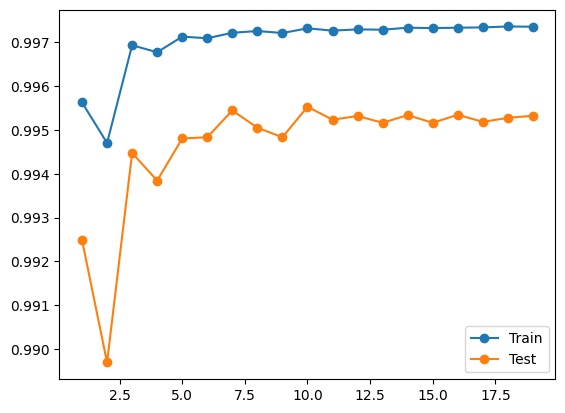

In [ ]:
from sklearn.metrics import accuracy_score
from matplotlib import pyplot as plt

train_scores, test_scores = list(), list()
# define the tree depths to evaluate
values = [i for i in range(1, 20)]
# evaluate a decision tree for each depth
for i in values:
 # configure the model
 model = RandomForestClassifier(n_estimators=i)
 # fit model on the training dataset
 model.fit(X_train, y_train)
 # evaluate on the train dataset
 train_yhat = model.predict(X_train)
 train_acc = accuracy_score(y_train, train_yhat)
 train_scores.append(train_acc)
 # evaluate on the test dataset
 test_yhat = model.predict(X_test)
 test_acc = accuracy_score(y_test, test_yhat)
 test_scores.append(test_acc)
 # summarize progress
 print('>%d, train: %.3f, test: %.3f' % (i, train_acc, test_acc))
# plot of train and test scores vs number of neighbors
plt.plot(values, train_scores, '-o', label='Train')
plt.plot(values, test_scores, '-o', label='Test')
plt.legend()
plt.show()

#### 2. Checking the CV consistency

In [ ]:
from sklearn.model_selection import cross_val_score
# Perform k-fold cross-validation on the training data
cv_scores = cross_val_score(rfc, X_train, y_train, cv=5)

# Print the cross-validation scores
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))
print("Standard Deviation of CV Accuracy:", np.std(cv_scores))

Cross-Validation Scores: [0.99509052 0.99487135 0.99516065 0.99544992 0.99513431]
Mean CV Accuracy: 0.9951413502550887
Standard Deviation of CV Accuracy: 0.0001850004233815316


### 3. Data-Leakage💀

Let's check how dependent/important our features to our target class

Feature: time_spent Score: 0.1544312079037336
Feature: originp Score: 0.05240026364637994
Feature: responp Score: 0.12726868205857278
Feature: flow_duration Score: 0.013850587563632768
Feature: fwd_pkts_tot Score: 0.003209222857594909
Feature: bwd_pkts_tot Score: 0.010920154743243008
Feature: fwd_data_pkts_tot Score: 0.00873451020608896
Feature: bwd_data_pkts_tot Score: 0.02067114547959682
Feature: fwd_pkts_per_sec Score: 0.01027635935046828
Feature: bwd_pkts_per_sec Score: 0.007231298579489576
Feature: flow_pkts_per_sec Score: 0.007306423966470379
Feature: down_up_ratio Score: 0.016703106882729798
Feature: fwd_header_size_tot Score: 0.037137368746490575
Feature: fwd_header_size_min Score: 0.041307138497884345
Feature: fwd_header_size_max Score: 0.039781110462684725
Feature: bwd_header_size_tot Score: 0.008303578116195885
Feature: bwd_header_size_min Score: 0.003547110181813664
Feature: bwd_header_size_max Score: 0.005019844592130611
Feature: flow_FIN_flag_count Score: 9.93592967722131

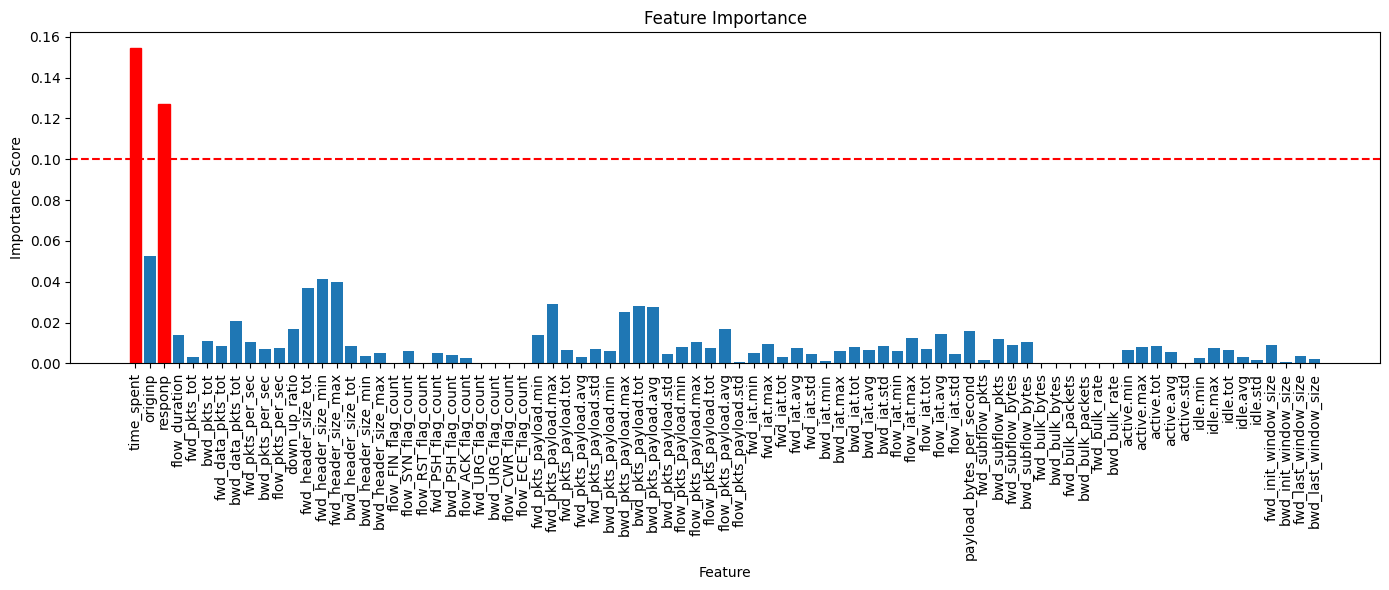

Mean importance score: 0.012048192771084338


In [ ]:
from matplotlib import pyplot as plt
# get importance
importance = rfc.feature_importances_
feature_names = undersampled_num_df.columns
threshold_max_importance_score = 0.100

for i, (feature, score) in enumerate(zip(feature_names, importance)):
    print('Feature:', feature, 'Score:', score)

# Plot feature importance
plt.figure(figsize=(14, 6))

# Plot feature importance
bars = plt.bar(feature_names, importance)
asdf
# Add color to bars exceeding the threshold
for bar, score in zip(bars, importance):
    if score > threshold_max_importance_score:
        bar.set_color('red')  # Set color to red for bars exceeding the threshold

plt.axhline(y=threshold_max_importance_score, color='r', linestyle='--', label='Threshold')  # Add threshold line
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.title('Feature Importance')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

# Calculate mean importance score
mean_importance = sum(importance) / len(importance)
print("Mean importance score:", mean_importance)


As you can see the mean of our **importance score is ~0.01**, but **'time_spent'** and **'responp'** is way off the mean (10 times more than the mean). It means that these 2 are really dependent to our target variable. So let's drop them.

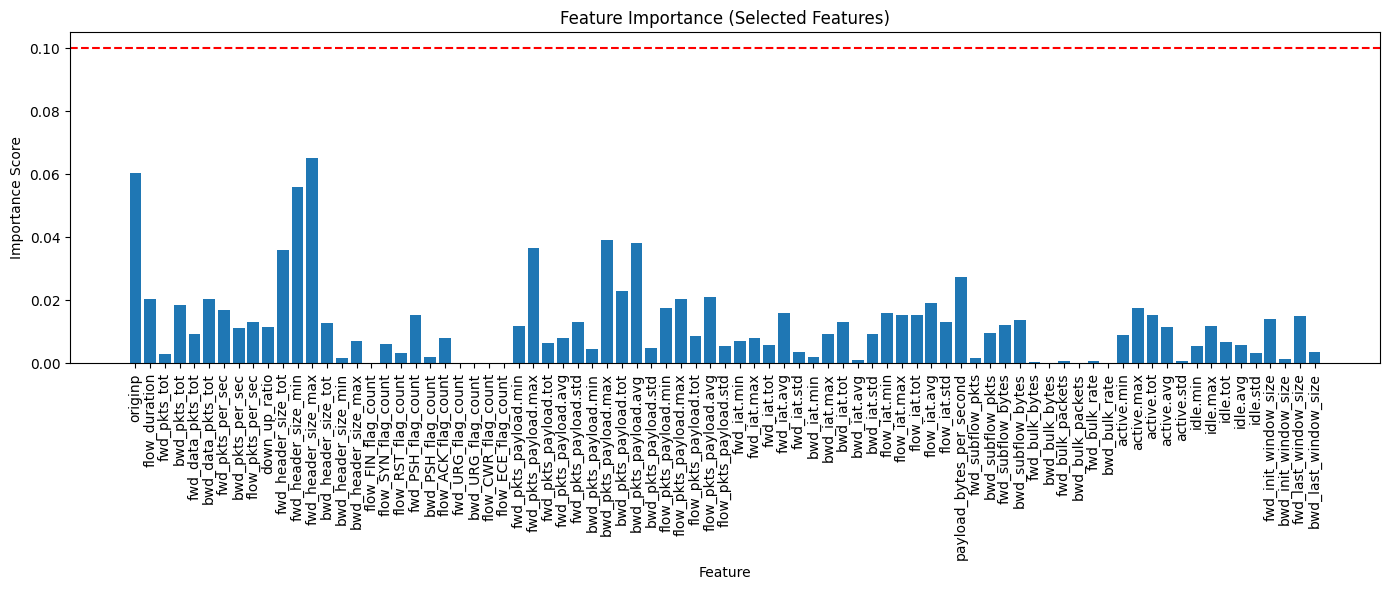

Mean importance score for selected features: 0.012345679012345682


In [ ]:

#we dropped the highest exceeding features
selected_features = undersampled_num_df.drop(['time_spent','responp'], axis = 1)
feature_names = selected_features.columns
y = undersampled_df['Target']  # Target variable
from sklearn.ensemble import RandomForestClassifier

# Assuming you've already imported necessary libraries and defined threshold_max_importance_score

# Train RandomForestClassifier on the selected features
rfc_selected = RandomForestClassifier()
rfc_selected.fit(selected_features, y)  # Assuming target_variable is defined elsewhere

# Get importance scores for the selected features
importance_selected = rfc_selected.feature_importances_

# Plot feature importance for selected features
plt.figure(figsize=(14, 6))

# Plot feature importance
bars = plt.bar(feature_names, importance_selected)  # Use importance_selected instead of importance

# Add color to bars exceeding the threshold
for bar, score in zip(bars, importance_selected):
    if score > threshold_max_importance_score:
        bar.set_color('red')  # Set color to red for bars exceeding the threshold

plt.axhline(y=threshold_max_importance_score, color='r', linestyle='--', label='Threshold')  # Add threshold line
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.title('Feature Importance (Selected Features)')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

# Calculate mean importance score for selected features
mean_importance_selected = sum(importance_selected) / len(importance_selected)
print("Mean importance score for selected features:", mean_importance_selected)




As you can see the mean of our **importance score is ~0.01**, but **'time_spent'** and **'responp'** is way off the mean (10 times more than the mean). It means that these 2 are really dependent to our target variable. So let's drop them.


In [ ]:

# Assuming 'Target' is your target variable
X = undersampled_num_df.drop(['time_spent','responp'], axis = 1) # Features
y = undersampled_df['Target']  # Target variable

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rfc = RandomForestClassifier()

# Train the classifier
rfc.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rfc.predict(X_test)

# Evaluate the classifier
print("[NEW] RANDOM FOREST CLASSIFIER\n")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

[NEW] RANDOM FOREST CLASSIFIER

Confusion Matrix:
 [[69482  1625]
 [ 7645 63829]]

Classification Report:
               precision    recall  f1-score   support

      Benign       0.90      0.98      0.94     71107
   Malicious       0.98      0.89      0.93     71474

    accuracy                           0.93    142581
   macro avg       0.94      0.94      0.93    142581
weighted avg       0.94      0.93      0.93    142581



In [ ]:
import pickle
filename = '/content/drive/MyDrive/Skripsi/Preprocessing/notebooks_skripsi/rfc_pickle.sav'
pickle.dump(rfc, open(filename, 'wb'))

In [ ]:
# load the model from disk
loaded_model = pickle.load(open(filename, 'rb'))
result = loaded_model.score(X_test, y_test)
print(result)

0.9349843246996444


# Guide Markdown:
https://medium.com/analytics-vidhya/the-ultimate-markdown-guide-for-jupyter-notebook-d5e5abf728fd